# Comparing drosophila transcriptional buffering efficiency with haploinsufficiency estimates in humans

In [21]:
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

In [2]:
gene_dict = {}

dros_buffering_path = "/Users/dj20y461/Downloads/Dros_buffering.tsv"

with open(dros_buffering_path) as dros_buffering_data:
    
    header = next(dros_buffering_data)
    
    for line in dros_buffering_data:
        
        gene_dict[line.split()[1]] = {} ## get the flybase gene ID
        gene_dict[line.split()[1]]["gene_name"] = line.split()[0] 
        gene_dict[line.split()[1]]["buffering"] = line.split()[2] 
        

In [3]:
## add names of human orthologs

human_orths_path = "/Users/dj20y461/Downloads/mart_export.txt"

with open(human_orths_path) as human_orths_data:
    
    header = next(human_orths_data)
    
    for line in human_orths_data:
    
        dros_ID = line.split()[0]

        if dros_ID in gene_dict:
            
            if len(line.split()) > 1:
                gene_dict[dros_ID]["human_orth_ENS_ID"] = line.split()[1]
                gene_dict[dros_ID]["human_orth_gene_name"] = line.split()[2]
            
            elif len(line.split()) == 1:
                gene_dict[dros_ID]["human_orth_ENS_ID"] = "none"
                gene_dict[dros_ID]["human_orth_gene_name"] = "none"
                
        else:
            print(dros_ID)
               

In [4]:
## tidy up the gene dictionary (some genes are not in the biomart outputs). 

for dros_ID in gene_dict:
    if "human_orth_ENS_ID" not in gene_dict[dros_ID]:
        gene_dict[dros_ID]["human_orth_ENS_ID"] = "none"
        gene_dict[dros_ID]["human_orth_gene_name"] = "none"

In [5]:
## finally, add the HI index data

In [6]:
human_HI_path = "/Users/dj20y461/Downloads/HI_Predictions_Version3.bed"

with open(human_HI_path) as human_HI_data:
    
    header = next(human_HI_data)
    
    for line in human_HI_data:
        
        human_gene_name = line.split()[3].split("|")[0]
        
        for dros_gene in gene_dict:
            if gene_dict[dros_gene]["human_orth_gene_name"] == human_gene_name:
                
                gene_dict[dros_gene]["human_HI"] = line.split()[4]


In [7]:
len(gene_dict)

373

In [8]:
non_buffered_HIs = []
partial_buffered_HIs = []
full_buffered_HIs = []
anti_buffered_HIs = []

for gene in gene_dict:
    
    if "human_HI" in gene_dict[gene]:
        
        if gene_dict[gene]["buffering"] == "anti":
            anti_buffered_HIs.append(float(gene_dict[gene]["human_HI"]))
        elif gene_dict[gene]["buffering"] == "non":
            non_buffered_HIs.append(float(gene_dict[gene]["human_HI"]))
        elif gene_dict[gene]["buffering"] == "partially":
            partial_buffered_HIs.append(float(gene_dict[gene]["human_HI"]))
        elif gene_dict[gene]["buffering"] == "fully":
            full_buffered_HIs.append(float(gene_dict[gene]["human_HI"]))

### Checking the distributions

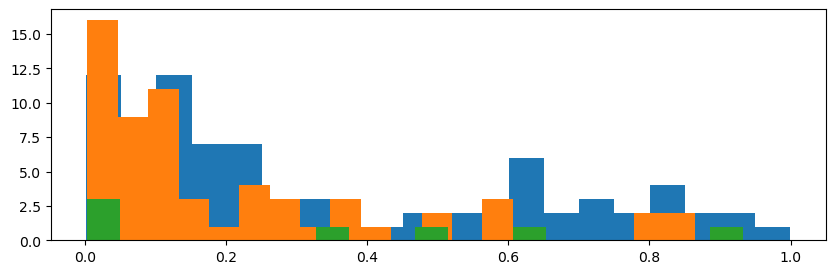

In [10]:
plt.figure(figsize = (10,3))

plt.hist(non_buffered_HIs,
         bins = 20)

plt.hist(partial_buffered_HIs,
         bins = 20)

plt.hist(full_buffered_HIs,
         bins = 20)

plt.show()

### Stats

The data are skewed, so a non-parametric test like MWU is best. I will use this to test for sig. differences pairwise between the three categories. 

In [11]:
stats.mannwhitneyu(non_buffered_HIs,
                   partial_buffered_HIs)

MannwhitneyuResult(statistic=3256.0, pvalue=0.003420728590426531)

In [12]:
stats.mannwhitneyu(non_buffered_HIs,
                   full_buffered_HIs)

MannwhitneyuResult(statistic=303.0, pvalue=0.856531431684387)

In [46]:
stats.mannwhitneyu(partial_buffered_HIs,
                   full_buffered_HIs)

MannwhitneyuResult(statistic=182.0, pvalue=0.5315533494229743)

Definitely significant differences in HI between the non-buffered and partially buffered gene sets. The fully buffered category has too few genes for it to be a useful test though. 

### Plotting

In [62]:
## prepare data to put in dataframe
all_HIs = non_buffered_HIs+partial_buffered_HIs+full_buffered_HIs
all_categories = ["none"]*len(non_buffered_HIs) + ["partial"]*len(partial_buffered_HIs) + ["full"]*len(full_buffered_HIs)

In [63]:
buffering_vs_HI_df = pd.DataFrame({"HI":all_HIs,
                                   "buffering": all_categories})

In [76]:
len(all_HIs)

151

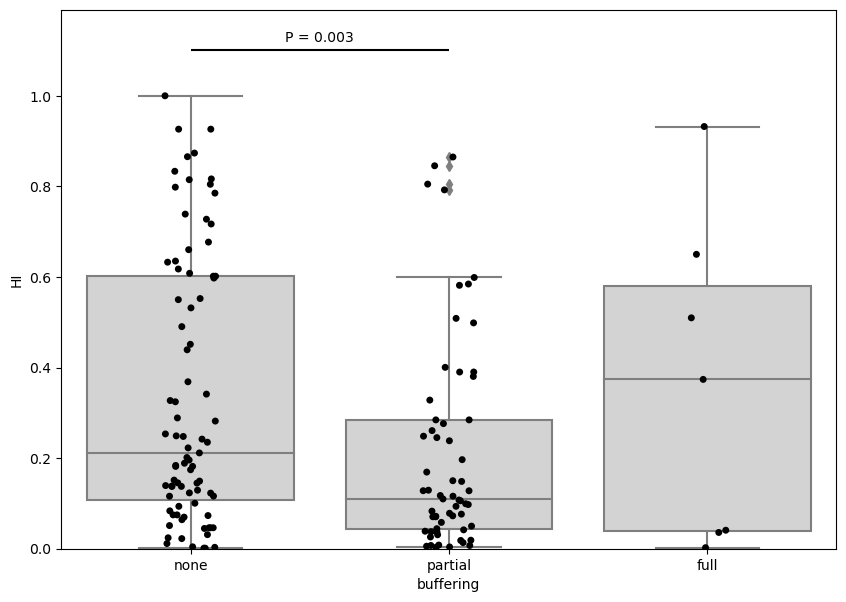

In [75]:
## plotting using seaborn so I can use the jitter plot function. 

plt.figure(figsize = (10,7))

sns.boxplot(data=buffering_vs_HI_df,
            x='buffering',
            y='HI',
            color='lightgray')

sns.stripplot(data=buffering_vs_HI_df,
              x='buffering',
              y='HI',
              color = "black",
              jitter=True);

plt.ylim(0,1.19)

plt.hlines(1.1, 
           0,
           1, 
           color = "black")

plt.text(0.5,
         1.12,
         "P = 0.003",
         ha = "center")

plt.savefig("/Users/dj20y461/Data_temp/Stickleback/Stickle_Y_comp/plots/Gene_expression/Dm_buffering_vs_HI.pdf")
plt.show()

# Doing the same for the data in Forouzanfar et al 2025

Here the data are more continuous. Buffering index is given for each gene, which reflects its ability to buffer transcriptional perturbation following depletion of a transcription co factor TIP60. 

In [104]:
gene_BIs

{'ENSMUSG00000000001': -0.025524918}

In [1]:
BI_path = "/Users/dj20y461/Downloads/sciadv.adr1492_data_s1_to_s3/adr1492_data_s1.txt"

gene_BI_dict = {}
gene_index = 0

with open(BI_path) as BI_data:
    
    headers = next(BI_data)
    
    for gene in BI_data:
        
        gene_ENS_ID = gene.split()[0]
        gene_name = gene.split()[1]
        BI_cell = gene.split()[4]
        LogFC_alpha = gene.split()[9]
        pvalue_alpha = gene.split()[10]

        if gene_index < 20000:
        
            gene_BI_dict[gene_ENS_ID] = {}
            gene_BI_dict[gene_ENS_ID]["gene_name"] = gene_name
            gene_BI_dict[gene_ENS_ID]["BI_cell"] = float(BI_cell)
            gene_BI_dict[gene_ENS_ID]["LogFC_alpha"] = float(LogFC_alpha)
            gene_BI_dict[gene_ENS_ID]["pvalue_alpha"] = float(pvalue_alpha)
            
        gene_index += 1
        

In [2]:
gene_BIs = [gene_BI_dict[gene_ENS_ID]["BI_cell"] for gene_ENS_ID in gene_BI_dict]

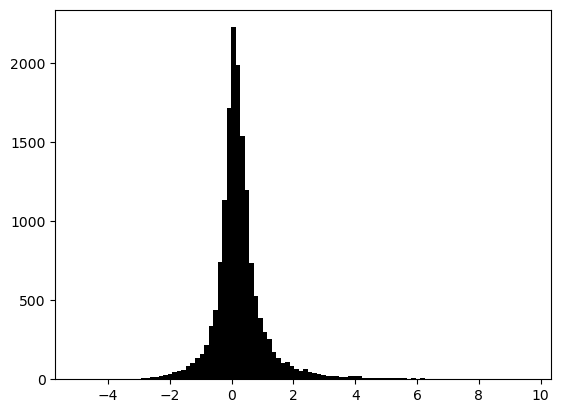

In [5]:
plt.hist(gene_BIs, bins = 100, color = "black")
plt.show()

## Filter the genes 

In [6]:
BI_data_filtered = {}

for gene in gene_BI_dict:        
    if all([str(gene_BI_dict[gene]["BI_cell"]) != "NaN",
            float(gene_BI_dict[gene]["pvalue_alpha"]) < 0.01,
            float(gene_BI_dict[gene]["BI_cell"]) >= 0]):
        
        BI_data_filtered[gene] = gene_BI_dict[gene]

In [7]:
len(BI_data_filtered)

2325

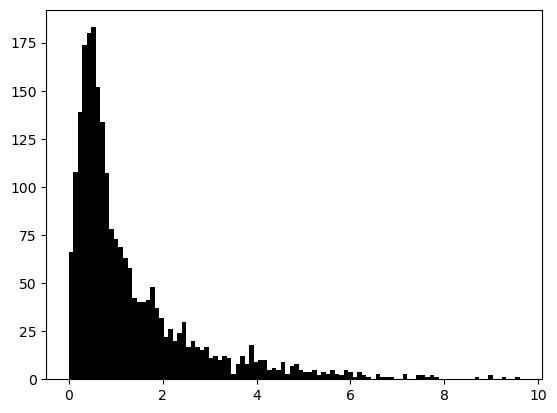

In [8]:
gene_BIs_filtered = [BI_data_filtered[gene_ENS_ID]["BI_cell"] for gene_ENS_ID in BI_data_filtered]
plt.hist(gene_BIs_filtered, bins = 100, color = "black")
plt.show()

Ok so there are 2325 genes that have significant transcriptional peterbation, and varying levels of BI_cell. So I will go ahead with these genes. 

I need to get the human orthologs, but can only do this for 500 genes at a time, so I'll output into 5 lists. 

In [229]:
BI_data_filtered

{'ENSMUSG00000000037': {'gene_name': 'Scml2',
  'BI_cell': 0.571007798,
  'LogFC_alpha': 1.582266734,
  'pvalue_alpha': 0.003219961},
 'ENSMUSG00000000078': {'gene_name': 'Klf6',
  'BI_cell': 0.961227281,
  'LogFC_alpha': -1.03637788,
  'pvalue_alpha': 0.002025602},
 'ENSMUSG00000000120': {'gene_name': 'Ngfr',
  'BI_cell': 0.656615884,
  'LogFC_alpha': 1.023050285,
  'pvalue_alpha': 0.007993664},
 'ENSMUSG00000000131': {'gene_name': 'Xpo6',
  'BI_cell': 0.403931053,
  'LogFC_alpha': -0.68064479,
  'pvalue_alpha': 0.001904575},
 'ENSMUSG00000000171': {'gene_name': 'Sdhd',
  'BI_cell': 1.158251232,
  'LogFC_alpha': -1.584268995,
  'pvalue_alpha': 1.24e-06},
 'ENSMUSG00000000184': {'gene_name': 'Ccnd2',
  'BI_cell': 3.553996466,
  'LogFC_alpha': -3.80808394,
  'pvalue_alpha': 0.000338381},
 'ENSMUSG00000000244': {'gene_name': 'Tspan32',
  'BI_cell': 2.695730813,
  'LogFC_alpha': -2.847239141,
  'pvalue_alpha': 5.51e-08},
 'ENSMUSG00000000290': {'gene_name': 'Itgb2',
  'BI_cell': 3.6471285

In [9]:
gene_set_1 = sorted(BI_data_filtered.keys())[0:500]
gene_set_2 = sorted(BI_data_filtered.keys())[500:1000]
gene_set_3 = sorted(BI_data_filtered.keys())[1000:1500]
gene_set_4 = sorted(BI_data_filtered.keys())[1500:2000]
gene_set_5 = sorted(BI_data_filtered.keys())[2000:]

In [10]:
file_number = 1

for i in [gene_set_1,
          gene_set_2,
          gene_set_3,
          gene_set_4,
          gene_set_5]:
    
    with open("/Users/dj20y461/Downloads/sciadv.adr1492_data_s1_to_s3/mouse_kept_gene_list_%s.txt" % file_number, 'w') as gene_list_out:
        
        for gene in i:
            gene_list_out.write("%s\n" % gene)
            
    file_number += 1
    

In [238]:
gene_index = 0 

for file in range(1,6):
    
    block_start = file*100
    block_end = 
    
    print(file, gene_index)
    
    with open("/Users/dj20y461/Downloads/sciadv.adr1492_data_s1_to_s3/gene_list_%s.txt" % file, 'w') as gene_list_out:
    
        for gene in sorted(BI_data_filtered.keys()):
            
            if file+1 < gene_index < (file+1)*100:
            
                gene_list_out.write("%s\n" % gene)
            
                gene_index += 1


1 100
2 200
3 300
4 400
5 500


In [11]:

subsample_gene_BIs = [BI_data_filtered[BI]["BI_cell"] for BI in gene_set_1 if str(BI) != "nan"] ## remove the nans


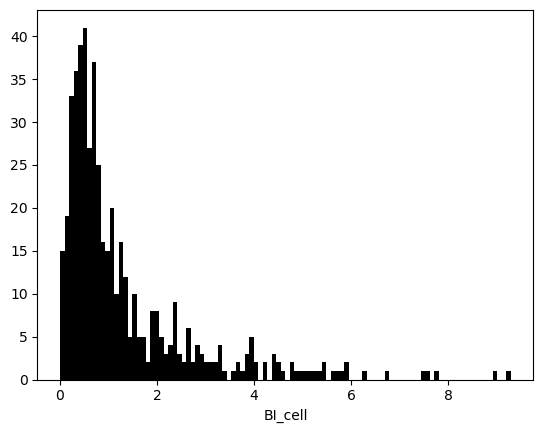

In [12]:
plt.hist(subsample_gene_BIs, bins = 100, color = "black")
plt.xlabel("BI_cell")
plt.show()

Distribution looks roughly the same. 

### Human orthologs found from biomart

In [13]:
human_orths_path = "/Users/dj20y461/Downloads/sciadv.adr1492_data_s1_to_s3/mouse_human_orthologs_list_all.txt"

with open(human_orths_path) as human_orths_data:
    
    header = next(human_orths_data)
    
    for line in human_orths_data:
    
        mouse_ID = line.split()[0]

        if mouse_ID in BI_data_filtered:
            
            if len(line.split()) == 4:
                BI_data_filtered[mouse_ID]["human_orth_ENS_ID"] = line.split()[2]
                BI_data_filtered[mouse_ID]["human_orth_gene_name"] = line.split()[3]
            
            else:
                BI_data_filtered[mouse_ID]["human_orth_ENS_ID"] = "none"
                BI_data_filtered[mouse_ID]["human_orth_gene_name"] = "none"
                
        #else:
        #    print(mouse_ID)
    
## tidy up the gene dictionary (some genes are not in the biomart outputs). 

for mouse_ID in BI_data_filtered:
    if "human_orth_ENS_ID" not in BI_data_filtered[mouse_ID]:
        BI_data_filtered[mouse_ID]["human_orth_ENS_ID"] = "none"
        BI_data_filtered[mouse_ID]["human_orth_gene_name"] = "none"

In [14]:
human_HI_path = "/Users/dj20y461/Downloads/HI_Predictions_Version3.bed"

with open(human_HI_path) as human_HI_data:
    
    header = next(human_HI_data)
    
    for line in human_HI_data:
        
        human_gene_name = line.split()[3].split("|")[0]
        
        for mouse_gene in BI_data_filtered:
            #print(mouse_gene)
            if BI_data_filtered[mouse_gene]["human_orth_gene_name"] == human_gene_name:
                
                BI_data_filtered[mouse_gene]["human_HI"] = float(line.split()[4])

In [15]:
for mouse_gene in BI_data_filtered:
    if 'human_HI' not in BI_data_filtered[mouse_gene]:
        print(mouse_gene)

ENSMUSG00000000486
ENSMUSG00000001285
ENSMUSG00000001403
ENSMUSG00000002504
ENSMUSG00000003072
ENSMUSG00000003518
ENSMUSG00000003526
ENSMUSG00000004044
ENSMUSG00000004085
ENSMUSG00000006057
ENSMUSG00000006526
ENSMUSG00000006720
ENSMUSG00000007029
ENSMUSG00000007827
ENSMUSG00000007892
ENSMUSG00000008682
ENSMUSG00000008683
ENSMUSG00000009569
ENSMUSG00000009828
ENSMUSG00000010755
ENSMUSG00000015711
ENSMUSG00000016257
ENSMUSG00000018102
ENSMUSG00000018398
ENSMUSG00000018848
ENSMUSG00000018907
ENSMUSG00000019689
ENSMUSG00000020042
ENSMUSG00000020156
ENSMUSG00000020312
ENSMUSG00000020491
ENSMUSG00000020589
ENSMUSG00000020617
ENSMUSG00000020812
ENSMUSG00000020814
ENSMUSG00000021023
ENSMUSG00000021185
ENSMUSG00000021207
ENSMUSG00000021268
ENSMUSG00000021338
ENSMUSG00000021747
ENSMUSG00000022008
ENSMUSG00000022054
ENSMUSG00000022055
ENSMUSG00000022095
ENSMUSG00000022724
ENSMUSG00000022780
ENSMUSG00000022856
ENSMUSG00000022956
ENSMUSG00000023147
ENSMUSG00000023307
ENSMUSG00000023826
ENSMUSG00000

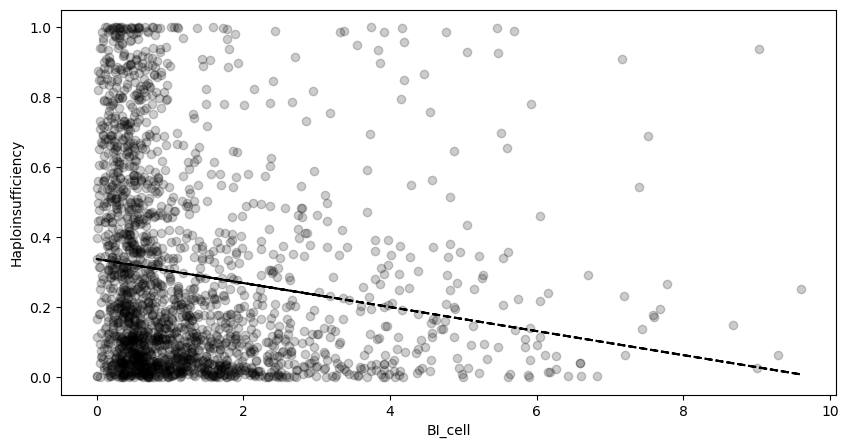

In [22]:
x = []
y = []

plt.figure(figsize = (10,5))

for mouse_gene in BI_data_filtered:
    
    if 'human_HI' in BI_data_filtered[mouse_gene]:
    
        plt.scatter(BI_data_filtered[mouse_gene]['BI_cell'],
                    BI_data_filtered[mouse_gene]['human_HI'],
                    color = "black", 
                    alpha = 0.2)
        
        x.append(BI_data_filtered[mouse_gene]['BI_cell'])
        y.append(BI_data_filtered[mouse_gene]['human_HI'])
        
## calculate regression line
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)  # poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(x, poly1d_fn(x), '--k') #'--k'=black dashed line, 'yo' = yellow circle marker
        
plt.xlabel("BI_cell")
plt.ylabel("Haploinsufficiency")
    
plt.show()

In [19]:
# 1. Define the exponential decay function
def exponential_decay(x, A, k, C):
    """
    Exponential decay function: y = A * exp(-k * x) + C
    A: Amplitude
    k: Decay constant
    C: Offset (asymptotic value)
    """
    return A * np.exp(-k * x) + C

Fitted parameters:
  A (Amplitude): 0.33
  k (Decay Constant): 1.9060
  C (Offset/Asymptote): 0.20


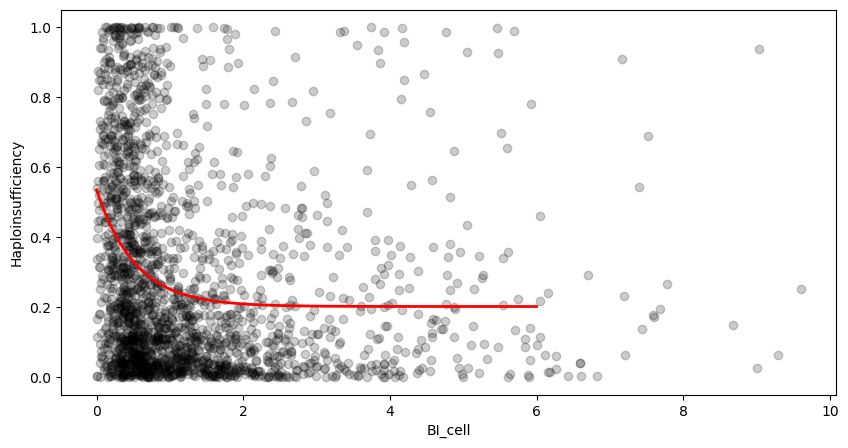

In [29]:
x = []
y = []

plt.figure(figsize = (10,5))

for mouse_gene in BI_data_filtered:
    
    if 'human_HI' in BI_data_filtered[mouse_gene]:
    
        plt.scatter(BI_data_filtered[mouse_gene]['BI_cell'],
                    BI_data_filtered[mouse_gene]['human_HI'],
                    color = "black", 
                    alpha = 0.2)
        
        x.append(BI_data_filtered[mouse_gene]['BI_cell'])
        y.append(BI_data_filtered[mouse_gene]['human_HI'])
        
## fit exponential decay curve

## generate initial guesses for the parameters of the model
initial_guesses = [max(y) - min(y), 0.5, min(y)]

params, covariance = curve_fit(exponential_decay, x, y, p0=initial_guesses)

# Extract the fitted parameters
A_fit, k_fit, C_fit = params


print("Fitted parameters:")
print(f"  A (Amplitude): {A_fit:.2f}")
print(f"  k (Decay Constant): {k_fit:.4f}") # k is often small, so more decimal places
print(f"  C (Offset/Asymptote): {C_fit:.2f}")

x_model = np.linspace(0, 6, 500)
y_model = exponential_decay(x_model, A_fit, k_fit, C_fit)

## plot the model line 
plt.plot(x_model, y_model, color='red', linewidth=2, label='Fitted Exponential Decay Model')


plt.xlabel("BI_cell")
plt.ylabel("Haploinsufficiency")
    
plt.show()

In [278]:
import numpy as np
from sklearn.linear_model import LinearRegression

BI_HI_array = np.column_stack((x, y))

In [280]:
reg = LinearRegression().fit(BI_HI_array, y)

In [281]:
reg

LinearRegression()

## Cleaning up the analysis 

there are a couple of things I could do to focus this analysis on the thing we are most interested in. 

1. I can remove negative values. These are not likely to be related to <i>transcriptional buffering</i> but more likely to other types of buffering (e.g. at the protein level or pathway level)

2. I can limit the genes I use to TIP60 target genes only. These are the ones most likely perturbed directly by the depletion assay. 

3. I could try to distinguish between classes of genes within those that have BI_cell = 0. At the moment these can be two types of gene. a) those that are perturbed but not buffered, and b) those that were not perturbed at all. If I understand correctly, I could use the LogFC_alpha values to use only those genes that are transcriptionally perturbed. I could then just use the BI_cell values from these genes.

I am waiting on responses from Manuel and Nacho currently, so can't move on 2. 1 is easy. 3 is the one I am most unsure of. So I will now take a look at the LogFC_alpha values. And perhaps see how they relate to the BI_cell scores. 